# Exercise no. 1: Sampling
Let $x_{a}(t) = 3 cos(3 π t) + 5 cos (5 π t)$ be a signal defined for $[tmin, tmax]=[-2, 2] \ s$ and zero elsewhere.

Implement a Python script that:
- Constructs and plots the analog signal $x_{a}(t)$ over the interval $[tmin, tmax]=[-6, 6] \ s$.
- Given a sampling rate $f_{c}$ (chosen appropriately), samples $xa(t)$ by creating a sequence $x[n]$ satisfying the Shannon theorem and reconstructs $x(t)$ from $x[n]$ using the reconstruction formula in the interval $[-6, 6] \ s$. Compare the signals obtained.
- Given a sampling rate $f_{c}$ (chosen appropriately), samples $xa(t)$ by creating a sequence $x[n]$ without satisfying the Shannon theorem and reconstructs $x(t)$ from $x[n]$ using the reconstruction formula in the interval $[-6, 6] \ s$. Compare the signals obtained.
- Plots the amplitude spectrum of $x[n]$ obtained in points 2 and 3. How do they differ?


**Note**. To implement the reconstruction formula, you can exploit 3 approaches: 1) by using 2 for cycles, 2) by using 1 for cycle, 3) without using for cycles.

**Hints**. Use numpy methods (_cos_, _sinc_), matplotlib.pyplot methods (_plot_, _stem_), scipy.fft methods (_fft_). See lecture notes for _fft_ usage.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
def define_signal(t):
    # Aux. function that defines the functional form of the signal.
    x = 3*np.cos(3*np.pi*t) + 5*np.cos(5*np.pi*t)
    return x

def reconstruction_2loops(tmin, tmax, fc):
    # This function apply the reconstruction formula starting from the samples of the signal xa.
    # The solution exploited here uses 2 for loops.
    # Accepts as input the tmin and tmax of the samples used for reconstruction, and the sampling frequency (fc).
    # Returns as output the analog signal, sampled signal, and reconstructed analog signal
    # Of course, analog signals are discrete on your computer. These are sampled with "high" sampling frequency, simulating an analog signal.

    tstep = .01
    t = np.arange(-6, 6+tstep, tstep)
    xa = define_signal(t) # defining the signal from -6 to 6 s
    xa[t<tmin] = 0 # zeroing the signal from -6 to -2 and from 2 to 6
    xa[t>tmax] = 0

    # As alternative solution:
    # 1) we could define xa as an array of zeroes and find the indices of -2 s and +2 s (see np.where()) and fill xa with the signal from -2 s to 2 s
    # 2) do not define the signal outside [-2,2] s

    Tc=1/fc
    tc = np.arange(-6, 6+Tc, Tc)
    xn = define_signal(tc)
    xn[tc<tmin] = 0
    xn[tc>tmax] = 0
    omegac = 2*np.pi*fc

    tr = t
    xa_r = np.zeros(tr.shape[0]) # or equivalently np.zeros(len(tr))

    for i in np.arange(tr.shape[0]): # loop over time samples at which the reconstruction formula is applied (x(t) = ...# recons. formula)
        for k in np.arange(xn.shape[0]):  # loop over k variable in the reconstruction formula to perform the sum()
            # The index k spans from 0 to N-1 to access xn[k] but you should shift sinc(...(t-kTc)) functions also with negative time shifts.
            # To do so:
            # 1) shift the index k back of N/2 samples
            # 2) access kTc values from the sampled time axis (you already have them in tc)
            tmp_xa_r = xn[k] * np.sinc((omegac/(2*np.pi)) * (tr[i] - tc[k]))
            xa_r[i] = xa_r[i] + tmp_xa_r # or equivalently xa_r[i] += tmp_xa_r
    plt.figure(figsize=(11,8))# figure size of (11,8) is of a A4 paper (landscape)
    plt.subplot(2,1,1)
    plt.plot(t, xa, 'k')
    plt.stem(tc, xn, 'r')
    plt.ylabel('xa(t), x[n]')
    plt.subplot(2,1,2)
    plt.plot(t, xa, 'k')
    plt.plot(tr, xa_r, 'b')
    plt.xlabel('t')
    plt.ylabel('xa(t)')
    plt.legend(['Analog signal', 'Reconstructed analog signal'])
    return xa, xn, xa_r

def reconstruction_1loop(tmin, tmax, fc):
    # This function apply the reconstruction formula starting from the samples of the signal xa.
    # The solution exploited here uses 1 for loop.
    # See comments in reconstruction() function.

    tstep = .01
    t = np.arange(-6, 6+tstep, tstep)
    xa = define_signal(t)
    xa[t<tmin] = 0
    xa[t>tmax] = 0

    Tc=1/fc
    tc = np.arange(-6, 6+Tc, Tc)
    xn = define_signal(tc)
    xn[tc<tmin] = 0
    xn[tc>tmax] = 0
    omegac = 2*np.pi*fc

    omegac=2*np.pi*fc
    tr = np.arange(-6, 6+tstep, tstep)
    xa_r = np.zeros(tr.shape[0])

    for i in np.arange(tr.shape[0]):
        # Instead of looping over k variable of the recon. formula (performing the sum()), use np.sum() method.
        # For the current time step at which reconstruct the signal value, sum all weighted shifted sinc().
        # Important: in Python the multiplication between ndarrays is element-wise (like MATLAB .*).
        xa_r[i] = np.sum(xn * np.sinc((omegac/(2*np.pi)) * (t[i]-tc)))

    plt.figure(figsize=(11,8))
    plt.subplot(2,1,1)
    plt.plot(t, xa, 'k')
    plt.stem(tc, xn, 'r')
    plt.ylabel('xa(t), x[n]')
    plt.subplot(2,1,2)
    plt.plot(t, xa, 'k')
    plt.plot(tr, xa_r, 'b')
    plt.xlabel('t')
    plt.ylabel('xa(t)')
    plt.legend(['Analog signal', 'Reconstructed analog signal'])
    return xa, xn, xa_r

Omega max: 15.707963267948966
Omegac (fc) according to Shannon: 78.53981633974483 (12.5)
Omegac (fc) not according to Shannon: 23.561944901923447 (3.7499999999999996)


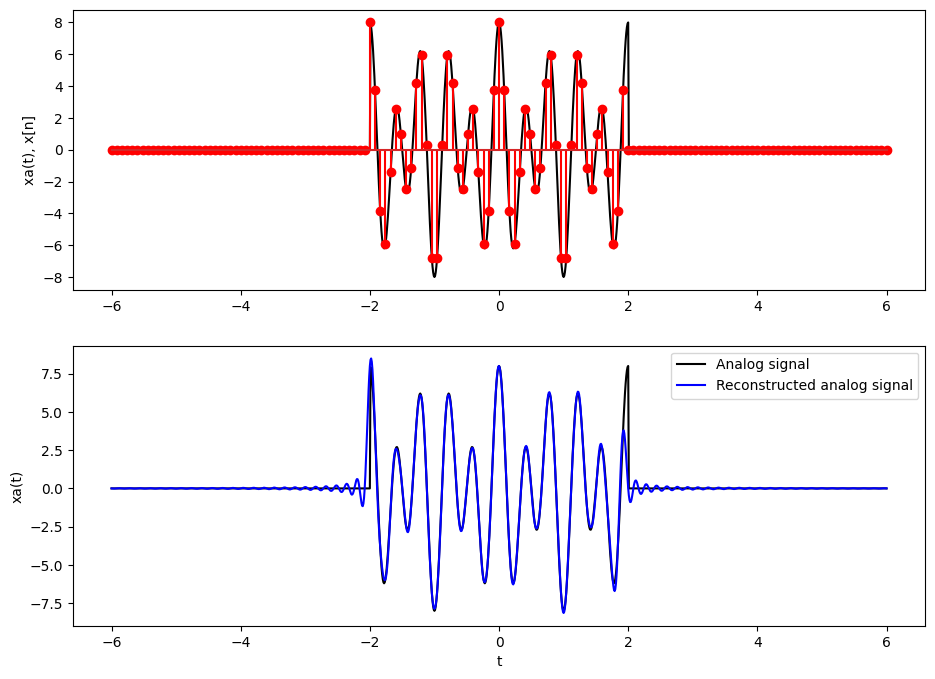

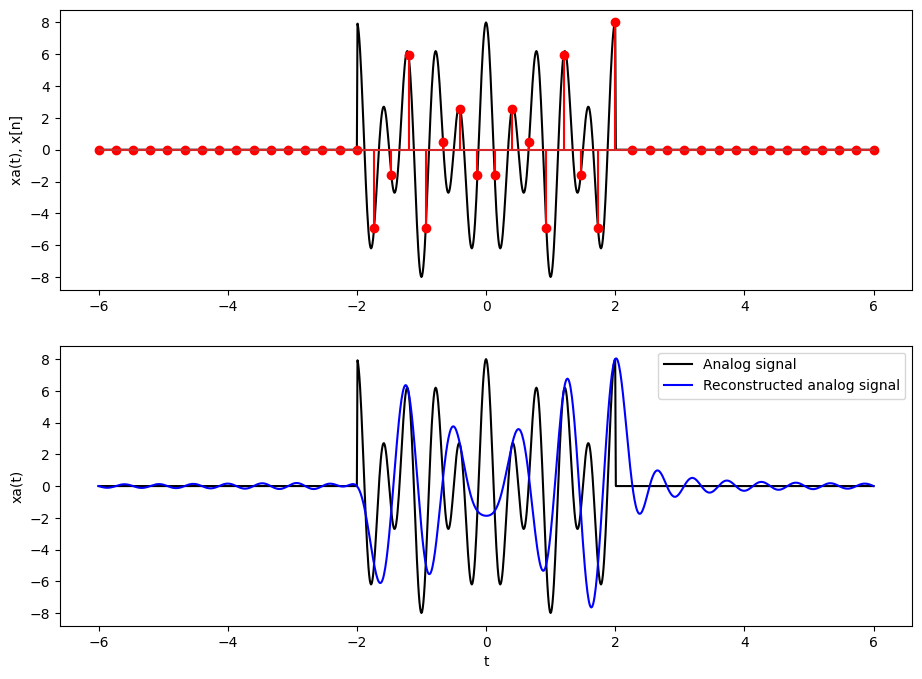

In [3]:
omega_max = 5*np.pi
print('Omega max: {0}'.format(omega_max))
omegac_shan = 5*omega_max
fc_shann = omegac_shan/(2*np.pi)
print('Omegac (fc) according to Shannon: {0} ({1})'.format(omegac_shan,
                                                           fc_shann))
omegac_noshan = 1.5*omega_max
fc_noshan = omegac_noshan/(2*np.pi)
print('Omegac (fc) not according to Shannon: {0} ({1})'.format(omegac_noshan,
                                                               fc_noshan))
xa_shan,xn_shan,xa_r_shan = reconstruction_2loops(-2, 2, fc_shann)
xa_noshan,xn_noshan,xa_r_noshan = reconstruction_2loops(-2,2,fc_noshan)

Text(0, 0.5, '|.|')

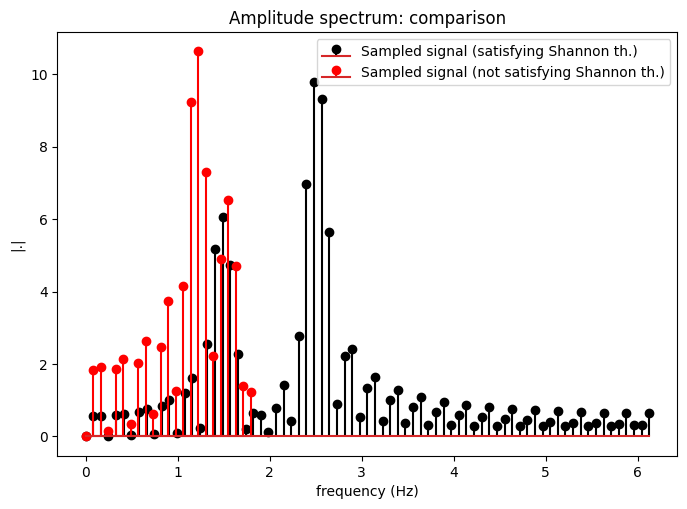

In [4]:
Xn_shan = scipy.fft.fft(xn_shan)
# By default it computes N-point DFT of the input sequence with N samples. You can specify L>>N to approximate the DTFT. See lecture notes and fft documentation.
nfft = Xn_shan.shape[0]

F_shan = np.arange(int(nfft/2))*(fc_shann/nfft)
Xn_shan = (1/fc_shann)*np.abs(Xn_shan[:int(nfft/2)])

Xn_noshan = scipy.fft.fft(xn_noshan)
nfft = Xn_noshan.shape[0]

F_noshan = np.arange(int(nfft/2))*(fc_noshan/nfft)
Xn_noshan = (1/fc_noshan)*np.abs(Xn_noshan[:int(nfft/2)])

'''
# plot by exploiting subplots (similar representation)
plt.figure(figsize=(8,11/2))
plt.subplot(2,1,1)
plt.stem(F_shan, Xn_shan, 'k', markerfmt='ko',)
plt.xlim([-.5, 5])
plt.ylabel('|.|')
plt.xlabel('Frequency (Hz)')
plt.title('Amplitude spectrum sampled signal (satisfying Shannon th.)')
plt.subplot(2,1,2)
plt.stem(F_noshan, Xn_noshan, 'k', markerfmt='ko',)
plt.xlim([-.5, 5])
plt.ylabel('|.|')
plt.xlabel('Frequency (Hz)')
plt.title('Amplitude spectrum sampled signal (not satisfying Shannon th.)')

plt.tight_layout() # this serves to avoid overlap between subplots (it automatically adjusts space between subplots)
'''

plt.figure(figsize=(8,11/2))
plt.stem(F_shan, Xn_shan, 'k', markerfmt='ko', label='Sampled signal (satisfying Shannon th.)')
plt.stem(F_noshan, Xn_noshan, 'r', markerfmt='ro', label='Sampled signal (not satisfying Shannon th.)')
plt.legend(loc='upper right')
plt.title('Amplitude spectrum: comparison')
plt.xlabel('frequency (Hz)')
plt.ylabel('|.|')